## Práctica 5: Procesamiento en el dominio frecuencial
### Autor: Juan Manuel Mena Hernandez
### Fecha: 24-03-2026


### EJERCICIO 1. CÁLCULO, VISUALIZACIÓN DE LA MAGNITUD DEL ESPECTRO DE FOURIER

En este ejercicio proponemos calcular y visualizar la magnitud del espectro de Fourier de una imagen. Para visualizar el espectro, aplicamos la FFT y desplazamos el componente de frecuencia cero al centro. Debido al alto rango dinámico, utilizamos una transformación logarítmica para poder interpretar los datos.

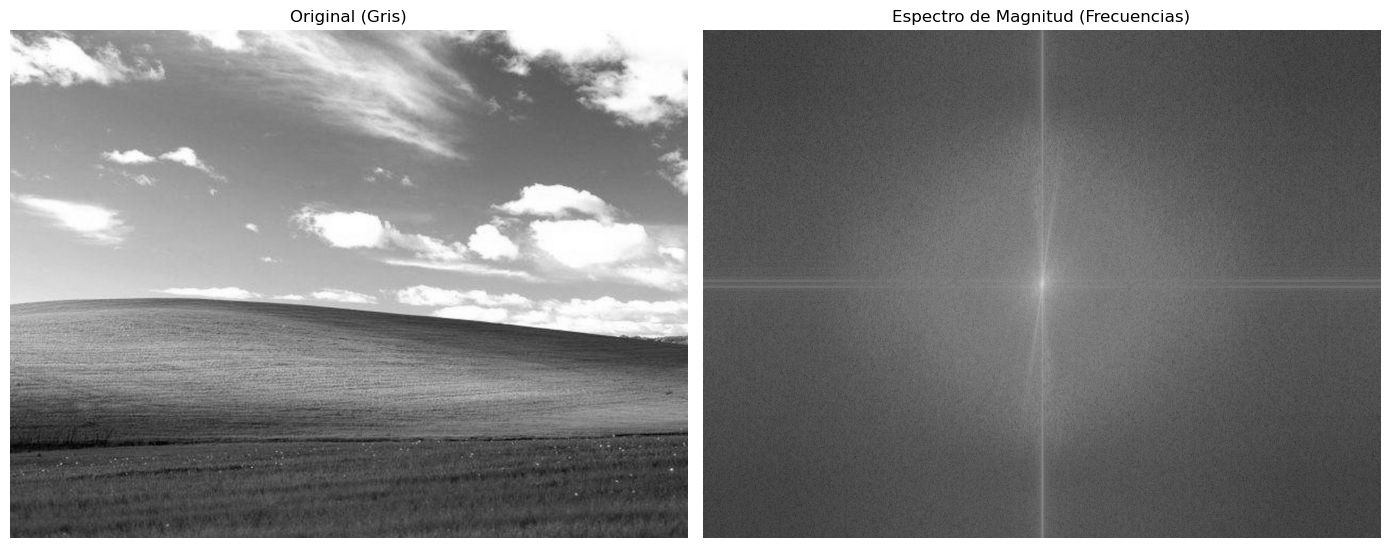

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg', 0)

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    # Cálculo de la FFT
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    ax1.imshow(img, cmap='gray')
    ax1.set_title('Original (Gris)')
    ax1.axis('off')
    ax2.imshow(magnitude_spectrum, cmap='gray')
    ax2.set_title('Espectro de Magnitud (Frecuencias)')
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

Este código hace tres cosas:

Primero, lee tu imagen en blanco y negro y revisa que se haya cargado sin problemas.

Segundo, le aplica Fourier. En lugar de mostrarte la imagen normal, esta herramienta crea un mapa visual que hace resaltar los patrones repetitivos y las texturas ocultas de la foto.

Tercero, abre una ventana que pone la foto original y el mapa de patrones una al lado de la otra para que las puedas comparar fácilmente.

### EJERCICIO 2. RECONSTRUCCIÓN MEDIANTE LA TRANSFORMADA INVERSA (IFFT)

En este ejercicio comprobaremos la integridad del proceso transformando la imagen al dominio frecuencial y regresando al dominio espacial sin aplicar filtros, asegurando que no hay pérdida de información.

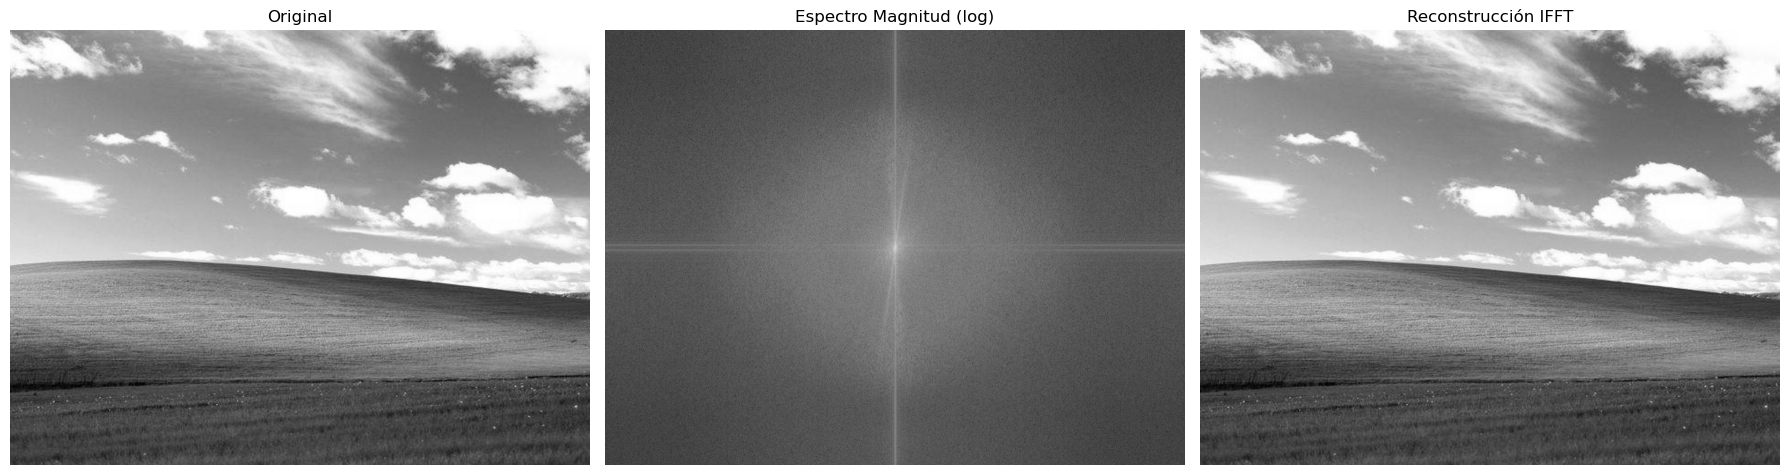

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg', 0)

if img is None:
    print("Error: No se pudo cargar 'imagen.jpg'.")
else:
    # FFT y dominio de la frecuencia
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

    # IFFT para volver al dominio espacial
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    ax1.imshow(img, cmap='gray')
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(magnitude_spectrum, cmap='gray')
    ax2.set_title('Espectro Magnitud (frecuencias)')
    ax2.axis('off')
    ax3.imshow(img_back, cmap='gray')
    ax3.set_title('Reconstrucción IFFT')
    ax3.axis('off')
    plt.tight_layout()
    plt.show()

Este código hace tres cosas reconstruir mediante la transformada inversa una imagen:

Primero, lee tu fotografía en blanco y negro y verifica que se haya cargado correctamente para evitar fallos.

Segundo, utiliza Fourier para convertir la imagen normal en un mapa visual de patrones o frecuencias. Inmediatamente después, hace el proceso inverso exacto: toma ese mapa y lo vuelve a calcular hacia atrás para reconstruir la imagen original por completo.

Tercero, abre una ventana dividida en tres partes para que puedas comparar visualmente la foto original, el mapa de patrones en el medio, y la foto reconstruida al final, demostrando que no se perdió información visual en este ida y vuelta matemático.

### EJERCICIO 3. FILTRO PASO BAJO IDEAL (ILPF)

En este ejercicio, se pide aplicar un filtro paso bajo Ideal a una imagen seleccionada El filtro ideal corta todas las frecuencias superiores a una distancia D0 del origen. Veremos cómo este corte abrupto genera el fenómeno de “ringing” o anillos en la imagen resultante.

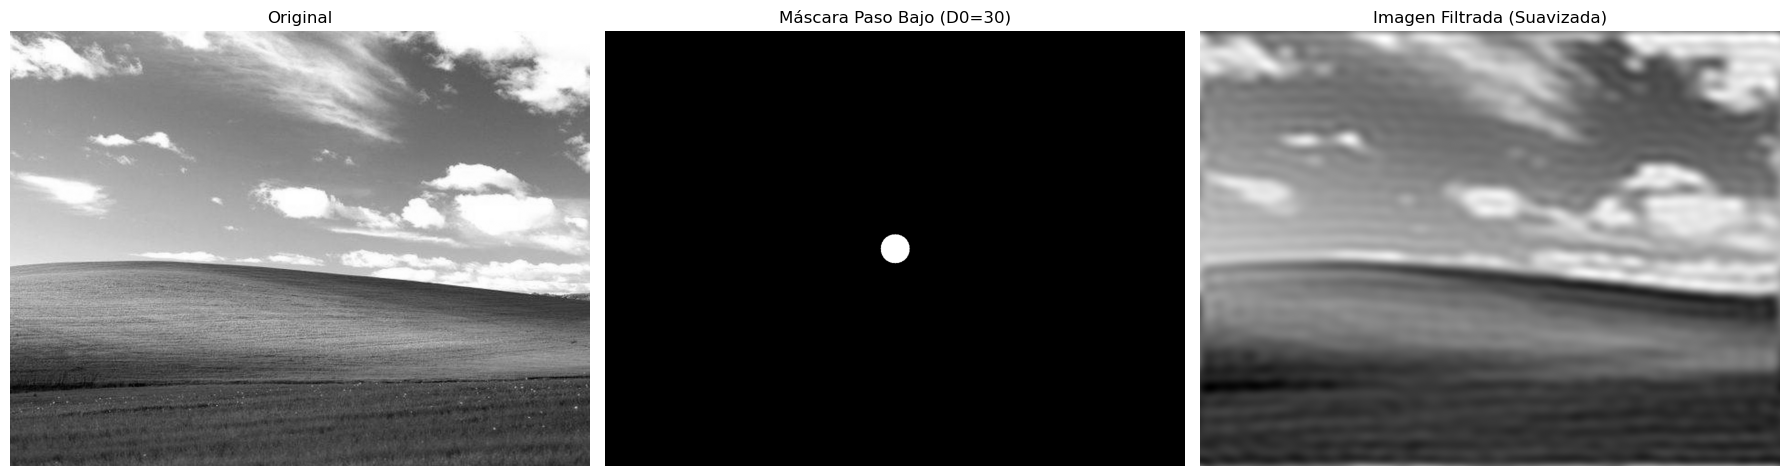

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg', 0)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Ir al dominio de la frecuencia
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# Crear la Máscara Ideal de Paso Bajo (Círculo blanco en fondo negro)
mask = np.zeros((rows, cols), np.uint8)
d0 = 30
cv2.circle(mask, (ccol, crow), d0, 1, -1)

# Aplicar máscara y volver al dominio del espacio
fshift_filtrado = fshift * mask
img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado)))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(mask, cmap='gray')
ax2.set_title(f'Máscara Paso Bajo (D0={d0})')
ax2.axis('off')
ax3.imshow(img_back, cmap='gray')
ax3.set_title('Imagen Filtrada (Suavizada)')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código suaviza una imagen de este modo:

Primero, carga la fotografía en blanco y negro y utiliza Fourier para convertirla en un mapa de frecuencias, centrando los datos para poder modificarlos de forma más sencilla.

Segundo, crea y aplica una "máscara" virtual en forma de círculo. Esta máscara funciona como un filtro que permite el paso únicamente de las frecuencias bajas, que representan los colores planos y las formas generales de la foto, y bloquea por completo las frecuencias altas, que corresponden a los bordes nítidos y los detalles finos.

Tercero, hace el cálculo matemático inverso para reconstruir la imagen a partir de los datos generados. Finalmente, abre una ventana dividida en tres partes para mostrarte la foto original, el círculo que se usó como máscara y el resultado final, el cual lucirá borroso o suavizado al haber perdido sus texturas principales.

### EJERCICIO 4. FILTRO PASO BAJO GAUSSIANO (GLPF)

En este ejercicio, se pide aplicar un filtro paso bajo Gaussiano a una imagen seleccionada. El filtro Gaussiano es el más suave de todos. Su función de transferencia es una campana de Gauss, lo que garantiza una eliminación total del efecto de ringing en la reconstrucción espacial.

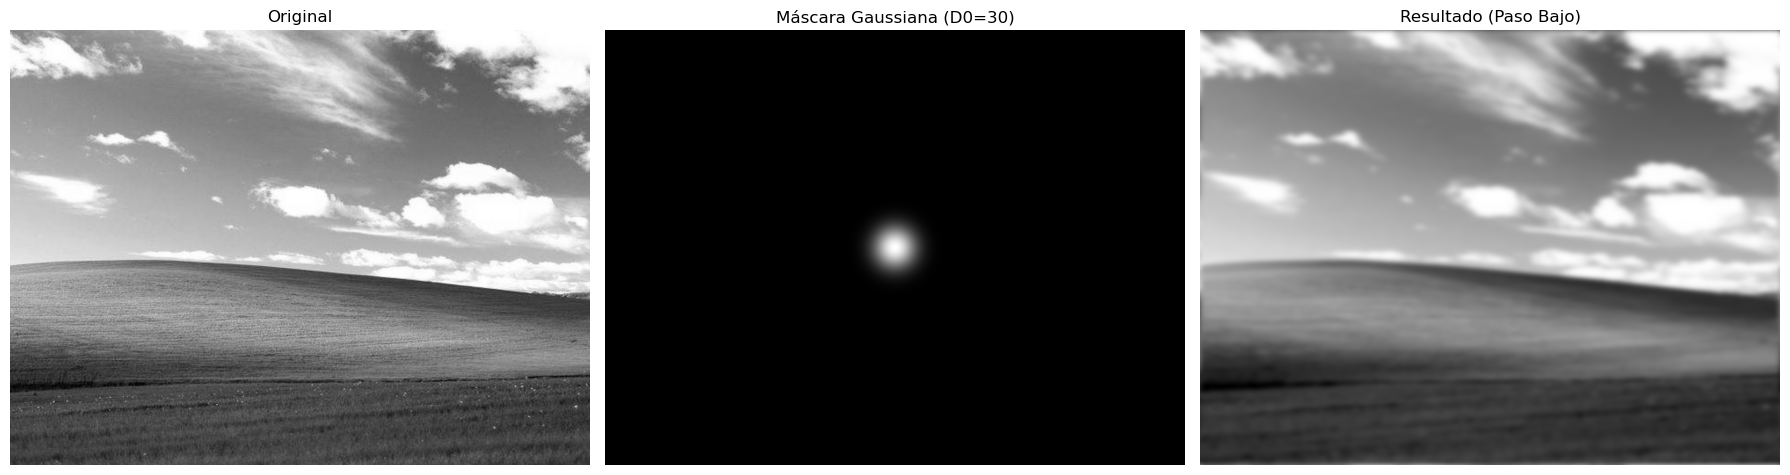

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg', 0)
rows, cols = img.shape

# Crear la malla de frecuencias y calcular distancias al centro
x, y = np.meshgrid(np.linspace(-cols/2, cols/2, cols), np.linspace(-rows/2, rows/2, rows))
distancias_cuadrado = x**2 + y**2

# Definir la Máscara Gaussiana de Paso Bajo
d0 = 30  # Radio de corte (desviación estándar)
mask = np.exp(-distancias_cuadrado / (2 * d0**2))

# Procesar en el dominio de la frecuencia
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
f_filtrado = fshift * mask

# Volver al dominio del espacio (IFFT)
img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(f_filtrado)))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(mask, cmap='gray')
ax2.set_title(f'Máscara Gaussiana (D0={d0})')
ax2.axis('off')
ax3.imshow(img_back, cmap='gray')
ax3.set_title('Resultado (Paso Bajo)')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código realiza tres acciones principales:

Primero, carga tu fotografía directamente en escala de grises y utiliza la herramienta matemática de Fourier para convertir la imagen normal en un mapa de frecuencias.

Segundo, crea y aplica un filtro virtual llamado "Gaussiano". A diferencia del círculo perfecto del ejemplo anterior, esta nueva máscara tiene bordes difuminados, lo que significa que bloquea los detalles finos y deja pasar los colores planos mediante una transición progresiva, esto evita que aparezcan distorsiones extrañas al desenfocar la foto.

Tercero, realiza el cálculo matemático inverso para reconstruir la imagen a su estado visual normal y abre una ventana dividida en tres partes para mostrarte la fotografía original, la forma difuminada de la nueva máscara y el resultado final suavizado.

### EJERCICIO 5. FILTRO PASO ALTO DE BUTTERWORTH (BHPF)

En este ejercicio, se pide aplicar un filtro paso Alto Butterworth a una imagen seleccionada Utilizado para el realce de bordes, este filtro permite un control preciso sobre la nitidez de la transición frecuencial, siendo muy útil en preprocesamiento de visión artificial.

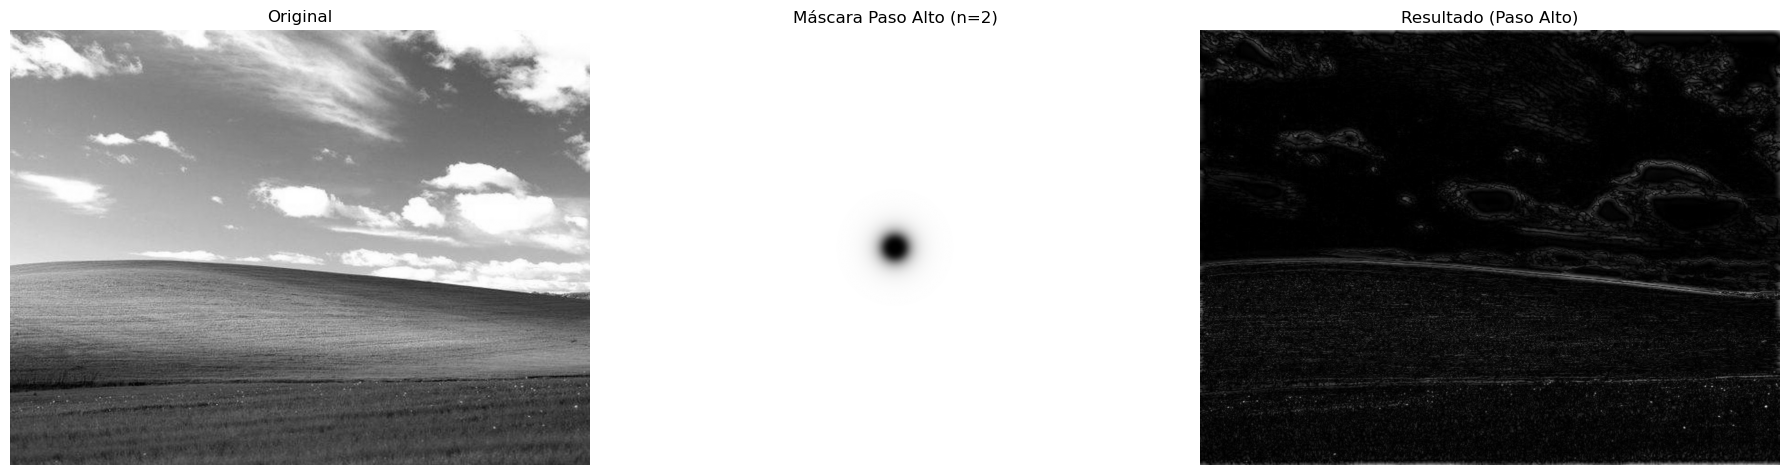

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg', 0)
rows, cols = img.shape

# Crear la malla de frecuencias y calcular distancias al centro
x, y = np.meshgrid(np.linspace(-cols/2, cols/2, cols), np.linspace(-rows/2, rows/2, rows))
d = np.sqrt(x**2 + y**2)

# Definir parámetros del filtro
d0 = 30  # Radio de corte
n = 2    # Orden del filtro

# Ecuación del filtro Butterworth de Paso Alto
mask = 1 / (1 + (d0 / (d + 1e-5))**(2*n))

# Procesar en el dominio de la frecuencia
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
f_filtrado = fshift * mask

# Volver al dominio del espacio (IFFT)
img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(f_filtrado)))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(mask, cmap='gray')
ax2.set_title(f'Máscara Paso Alto (n={n})')
ax2.axis('off')
ax3.imshow(img_back, cmap='gray')
ax3.set_title('Resultado (Paso Alto)')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código resalta los contornos de una imagen.

Primero, carga la fotografía en blanco y negro y utiliza Fourier para transformarla en un mapa de frecuencias.

Segundo, crea y aplica un filtro virtual llamado Butterworth de paso alto. Este filtro bloquea las frecuencias bajas, que son los colores planos y el fondo, y permite el paso exclusivo de las frecuencias altas, que son los detalles finos y los bordes.

Tercero, realiza el cálculo inverso para reconstruir la fotografía y abre una ventana dividida en tres partes para mostrarte la foto original, la forma exacta de la máscara aplicada y el resultado final.

### EJERCICIO 6. FILTRO PASO ALTO GAUSSIANO (GHPF)

En este ejercicio, se pide aplicar un filtro paso alto Gaussiano a una imagen seleccionada. Este filtro se emplea para obtener una detección de bordes extremadamente limpia y suave, ideal para resaltar microestructuras en imágenes médicas o satelitales.

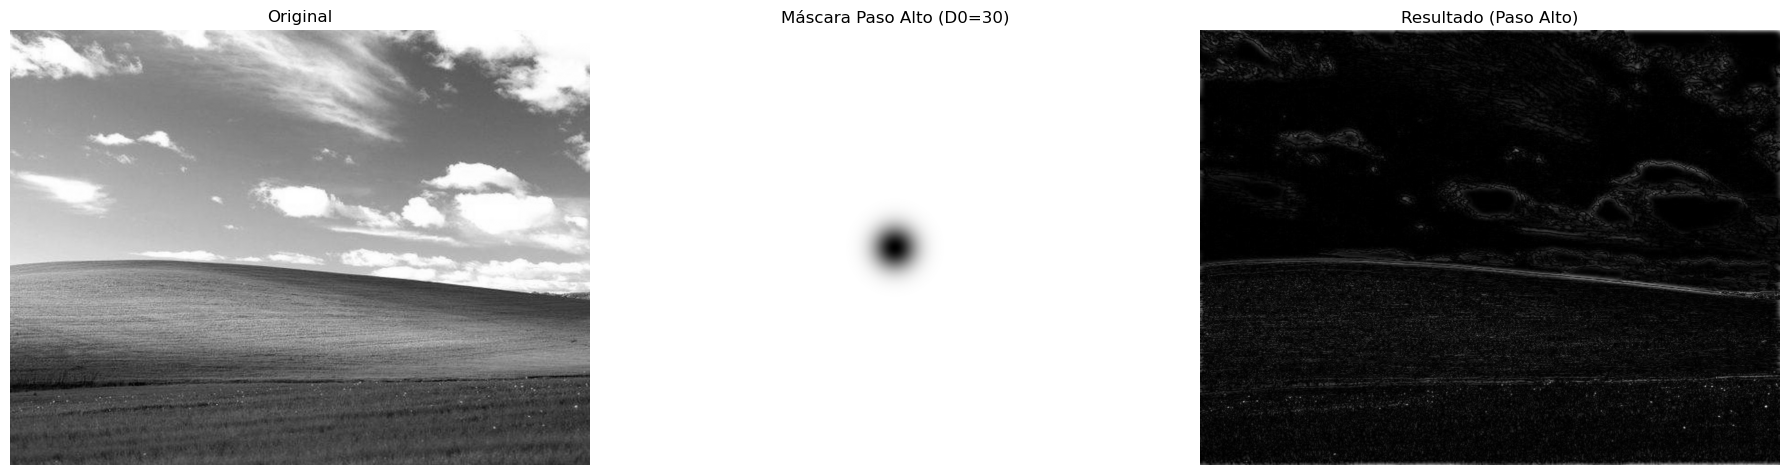

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg', 0)
rows, cols = img.shape

# Crear la malla de frecuencias y calcular distancias al centro
x, y = np.meshgrid(np.linspace(-cols/2, cols/2, cols), np.linspace(-rows/2, rows/2, rows))
distancias_cuadrado = x**2 + y**2

# Definir la Máscara Gaussiana de Paso Alto
d0 = 30  # Radio de corte
mask = 1 - np.exp(-distancias_cuadrado / (2 * d0**2))

# Procesar en el dominio de la frecuencia
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
f_filtrado = fshift * mask

# Volver al dominio del espacio (IFFT)
img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(f_filtrado)))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(mask, cmap='gray')
ax2.set_title(f'Máscara Paso Alto (D0={d0})')
ax2.axis('off')
ax3.imshow(img_back, cmap='gray')
ax3.set_title('Resultado (Paso Alto)')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código extrae y resalta los bordes de una fotografía con un acabado suave y sin distorsiones.

Primero, carga tu imagen directamente en blanco y negro y utiliza Fourier para convertirla en un mapa de frecuencias.

Segundo, crea y aplica una máscara matemática conocida como "Gaussiana de paso alto". Esta máscara bloquea las frecuencias bajas y permite el paso exclusivo de las frecuencias altas.

Tercero, realiza el proceso inverso para reconstruir la imagen a su estado visual estándar. Finalmente, dibuja una ventana dividida en tres secciones para mostrarte la fotografía original, la forma de la máscara aplicada y el resultado final.

### EJERCICIO 7. ELIMINACIÓN DE RUIDO PERIÓDICO MEDIANTE FILTRO DE MUESCA (NOTCH)

En este ejercicio, se pide aplicar un filtro de Muesca a una imagen seleccionada. El ruido periódico (como interferencias eléctricas) aparece como puntos brillantes en el espectro. Con un filtro de muesca, podemos “anular” esos puntos específicos para limpiar la imagen.

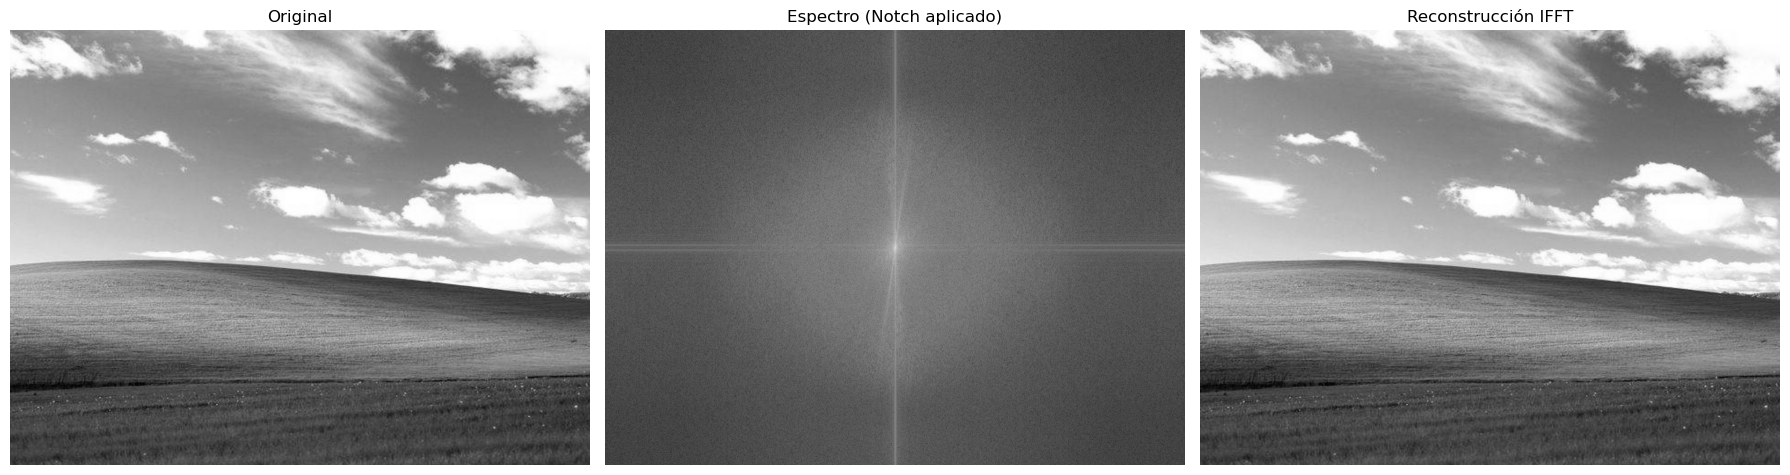

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg', 0)
rows, cols = img.shape

# Ir al dominio de la frecuencia
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# Crear el Espectro de Magnitud para visualizar los picos de ruido
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

# Aplicar el Filtro de Muesca (Notch) para anular frecuencias específicas (ruido)
fshift[100:105, 100:105] = 0
fshift[rows-105:rows-100, cols-105:cols-100] = 0

# Volver al dominio del espacio (IFFT)
f_ishift = np.fft.ifftshift(fshift)
img_back = np.abs(np.fft.ifft2(f_ishift))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(magnitude_spectrum, cmap='gray')
ax2.set_title('Espectro (Notch aplicado)')
ax2.axis('off')
ax3.imshow(img_back, cmap='gray')
ax3.set_title('Reconstrucción IFFT')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código limpia patrones de ruido repetitivo en una fotografía.

Primero, carga la imagen en blanco y negro y utiliza Fourier para transformarla en un mapa de frecuencias, creando una representación visual que permite identificar fácilmente las interferencias.

Segundo, aplica un filtro manual conocido como de muesca o Notch. En lugar de borrar zonas enteras, este método recorta zonas muy concretas dentro del mapa, eliminando así frecuencias específicas que suelen ser las culpables de generar rayas molestas sobre la imagen.

Tercero, hace el proceso inverso para reconstruir la fotografía a partir de los datos limpios y abre una ventana de tres paneles para mostrarte la foto original, el mapa de frecuencias modificado y la imagen final restaurada.

### EJERCICIO 8. APLICAR UN FILTRADO HOMOMÓRFICO

En este ejercicio se pide aplicar un filtrado Homomórfico para mediante tratamiento logarítmico corregir la iluminación de una imagen a elegir.

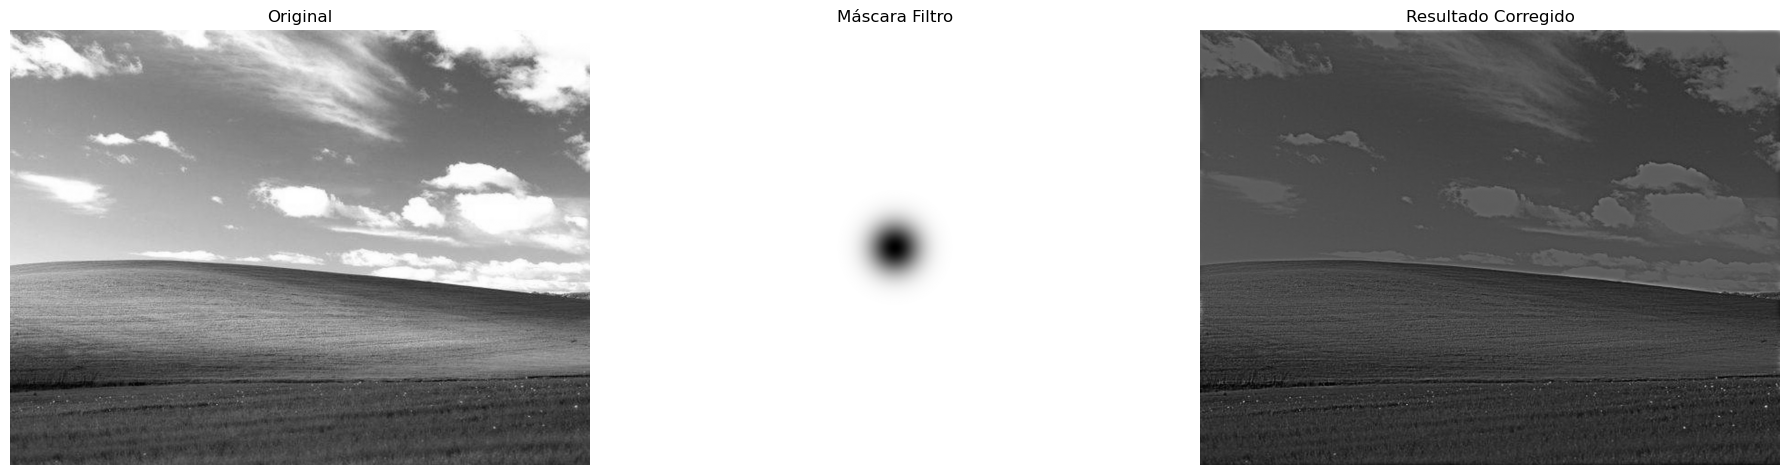

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagen.jpg', 0)
# Evitamos log(0) y trabajamos en float64
img_float = np.float64(img) + 1.0
img_log = np.log(img_float)
rows, cols = img.shape
x, y = np.meshgrid(np.linspace(-cols/2, cols/2, cols), np.linspace(-rows/2, rows/2, rows))
d2 = x**2 + y**2

# Filtro Homomórfico (Parámetros ajustados)
rh, rl, c, d0 = 1.5, 0.5, 1.0, 50
mask = (rh - rl) * (1 - np.exp(-c * (d2 / (d0**2)))) + rl

# FFT y Filtrado
f = np.fft.fftshift(np.fft.fft2(img_log))
res_f = f * mask

# Inversa y Exponencial
res_ifft = np.fft.ifft2(np.fft.ifftshift(res_f))
# Usamos np.real para evitar problemas de fase
res_exp = np.exp(np.real(res_ifft)) - 1.0

# Normalización ROBUSTA
res_exp = np.nan_to_num(res_exp)
# Re-escalado manual para asegurar visibilidad
res_final = cv2.normalize(res_exp, None, 0, 255, cv2.NORM_MINMAX)
res_final = np.uint8(np.clip(res_final, 0, 255))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(mask, cmap='gray')
ax2.set_title('Máscara Filtro')
ax2.axis('off')
ax3.imshow(res_final, cmap='gray')
ax3.set_title('Resultado Corregido')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código corrige problemas de iluminación y mejora los detalles ocultos en una fotografía.

Primero, carga la imagen en blanco y negro y la prepara matemáticamente calculando su logaritmo. Esto sirve para separar la luz ambiental que ilumina la escena de las texturas y colores reales de los objetos fotografiados.

Segundo, utiliza Fourier para convertir la imagen en un mapa de frecuencias y le aplica un filtro especial llamado Homomórfico. Esta máscara está diseñada para reducir las luces demasiado fuertes o las sombras profundas que afectan a toda la foto, y al mismo tiempo resaltar los detalles finos y los contornos.

Tercero, realiza el cálculo matemático inverso usando una función exponencial para devolver la imagen a su estado visual normal y reajusta automáticamente los tonos para que se vean correctamente. Luego, abre una ventana dividida en tres partes para mostrarte la foto original, la forma del filtro aplicado y el resultado final con una iluminación mucho más equilibrada.

### EJERCICIO 9. APLICAR UN ÉNFASIS DE ALTA FRECUENCIA

En este ejercicio se pide realizar un énfasis de alta frecuencia a una imagen a elegir. El énfasis de alta frecuencia combina el paso alto con una constante para no perder el fondo.

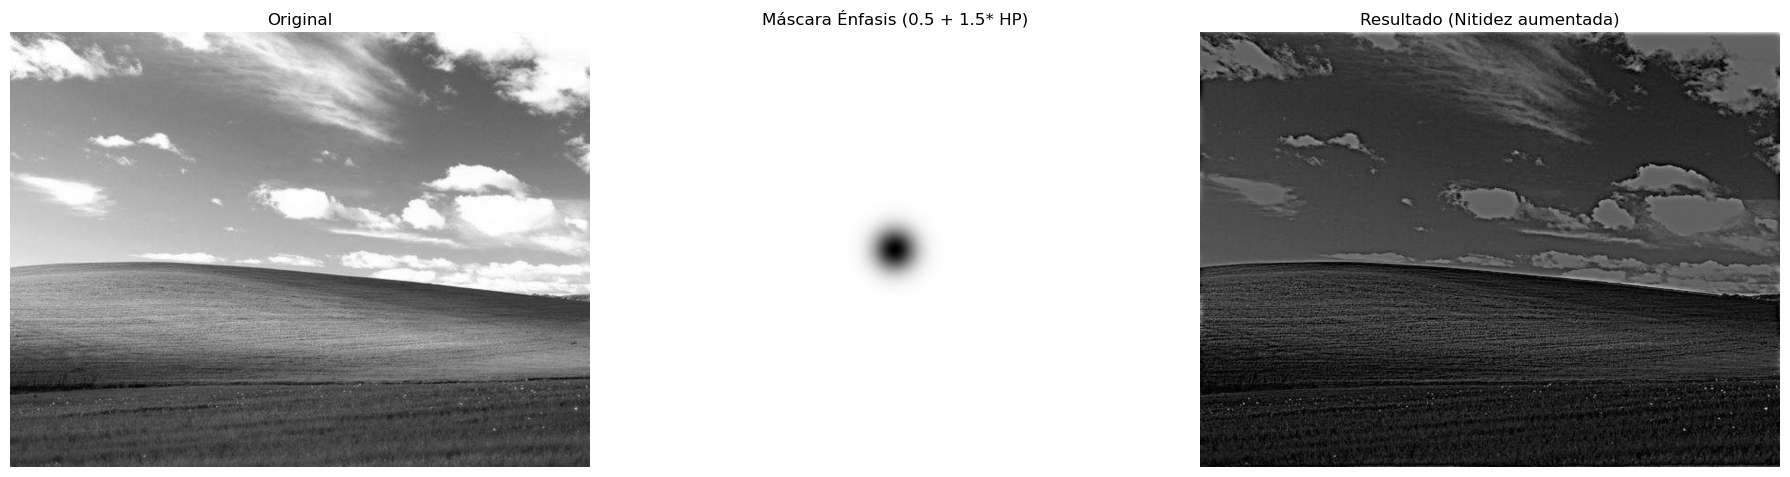

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Cargar imagen en gris
img = cv2.imread('imagen.jpg', 0)
rows, cols = img.shape

# Crear malla de frecuencias y Filtro Paso Alto Gaussiano (HP)
x, y = np.meshgrid(np.linspace(-cols/2, cols/2, cols), np.linspace(-rows/2, rows/2, rows))
d0 = 30
hp = 1 - np.exp(-(x**2 + y**2) / (2 * d0**2))

# Máscara de Énfasis: a + b * HP
a, b = 0.5, 1.5
mask = a + b * hp

# Procesar en frecuencia
f = np.fft.fftshift(np.fft.fft2(img))
f_filtrado = f * mask

# Reconstruir (IFFT)
res = np.abs(np.fft.ifft2(np.fft.ifftshift(f_filtrado)))

# Normalizar correctamente para visualización
res_norm = cv2.normalize(res, None, 0, 255, cv2.NORM_MINMAX)
res_final = np.uint8(res_norm)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(mask, cmap='gray')
ax2.set_title(f'Máscara Énfasis ({a} + {b}* HP)')
ax2.axis('off')
ax3.imshow(res_final, cmap='gray')
ax3.set_title('Resultado (Nitidez aumentada)')
ax3.axis('off')
plt.tight_layout()
plt.show()

Este código aumenta la nitidez y resalta los detalles de una fotografía.

Primero, carga la imagen directamente en blanco y negro y utiliza Fourier para convertirla en un mapa de frecuencias.

Segundo, usa un filtro especial llamado de énfasis de alta frecuencia. Este filtro retiene una parte de los colores planos y las sombras originales de la foto, además multiplica y resalta intensamente los bordes y las texturas aumentar su protagonismo.

Tercero, realiza el cálculo inverso para reconstruir la imagen, ajusta automáticamente la iluminación para que los píxeles se vean correctamente en pantalla, y abre una ventana de tres paneles para mostrarte la foto original, la forma de la máscara aplicada y el resultado final con una nitidez muy superior.

### EJERCICIO 10. APLICAR FILTRADO PARA REDUCIR RUIDO Y MEJORAR CALIDAD VISUAL

El objetivo de este ejercicio es aplicar técnicas de filtrado para reducir ruido y mejorar la calidad visual de una imagen digital, analizando los efectos producidos en cada etapa del proceso.

Cada estudiante deberá seleccionar una imagen libre, ya sea una fotografía propia o procedente de bancos de imágenes gratuitos. La imagen elegida deberá tener una resolución adecuada
(se recomienda un mínimo de 1024×768 píxeles), presentar suficiente nivel de detalle —como
escenas urbanas, paisajes, personas u objetos— y permitir su conversión a escala de grises.

A partir de la imagen seleccionada, se realizará el siguiente trabajo. En primer lugar, se
convertirá la imagen a escala de grises y se generará una versión degradada mediante la adición
de ruido gaussiano artificial.

Posteriormente, se aplicará un método de reducción de ruido mediante un filtro Gaussiano
de suavizado. De esta fase deberán mostrarse y comentarse la imagen original, la imagen con
ruido y la imagen suavizada, describiendo visualmente los efectos del filtrado.

A continuación, se llevará a cabo una etapa de mejora de detalles aplicando una técnica de
realce de bordes basada en la máscara de enfoque (Unsharp Mask) (Aquí usaremos dominio
espacial). Se deberán mostrar y comentar la imagen suavizada y la imagen final mejorada,
analizando las diferencias apreciables entre ambas.

Finalmente, se presentará una comparación visual conjunta en una única figura que incluya
la imagen original, la imagen con ruido, la imagen suavizada y la imagen final mejorada, con el
fin de evaluar de forma global los resultados obtenidos.

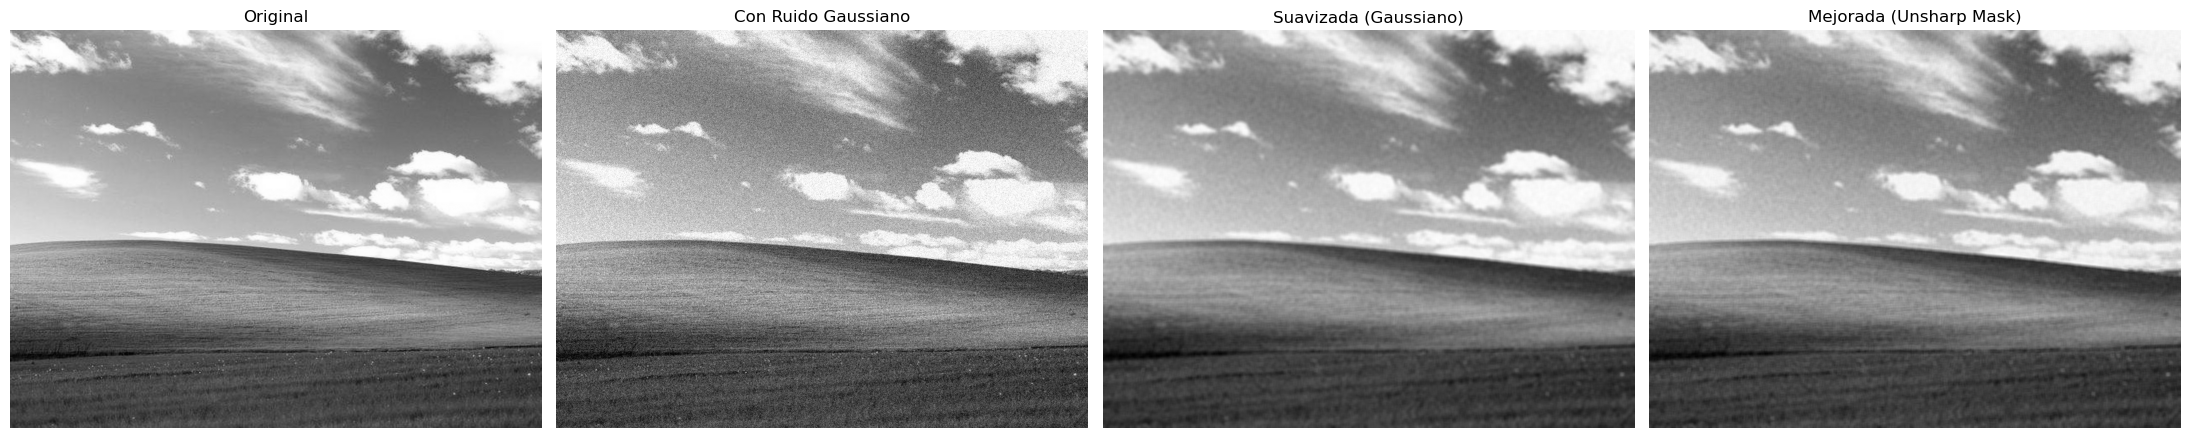

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen y convertir a escala de grises
img_color = cv2.imread('imagen.jpg')
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY) if img_color is not None else None

if img is None:
    raise ValueError("No se pudo cargar 'imagen.jpg'.")

# 2. Añadir ruido gaussiano artificial
mean = 0
sigma = 25
gauss = np.random.normal(mean, sigma, img.shape).astype(np.float32)
img_ruido = cv2.add(img.astype(np.float32), gauss)
img_ruido = np.clip(img_ruido, 0, 255).astype(np.uint8)

# 3. Suavizado con filtro Gaussiano
img_suavizada = cv2.GaussianBlur(img_ruido, (9, 9), 10.0)

# 4. Realce de detalles con Unsharp Mask
img_unsharp = cv2.addWeighted(img_suavizada, 1.5, cv2.GaussianBlur(img_suavizada, (9, 9), 10.0), -0.5, 0)

# 5. Comparación visual conjunta
fig, axs = plt.subplots(1, 4, figsize=(22, 7))
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(img_ruido, cmap='gray')
axs[1].set_title('Con Ruido Gaussiano')
axs[1].axis('off')
axs[2].imshow(img_suavizada, cmap='gray')
axs[2].set_title('Suavizada (Gaussiano)')
axs[2].axis('off')
axs[3].imshow(img_unsharp, cmap='gray')
axs[3].set_title('Mejorada (Unsharp Mask)')
axs[3].axis('off')
plt.tight_layout()
plt.show()

Este código realiza cuatro acciones principales para simular, limpiar y restaurar una fotografía afectada por ruido visual.

Primero, carga la imagen a color, la convierte inmediatamente a escala de grises y verifica que el archivo se haya leído correctamente para evitar fallos en el programa.

Segundo, ensucia intencionalmente la foto añadiéndole "ruido gaussiano" artificial, simulando un efecto de granulado simulando una cámara de baja calidad.

Tercero, aplica un filtro de suavizado para intentar limpiar ese ruido y difuminar los granos, e inmediatamente después utiliza una técnica llamada "máscara de enfoque" (Unsharp Mask) para recuperar la nitidez de los bordes y los detalles que se volvieron borrosos durante el proceso de limpieza.

Cuarto, dibuja una gran ventana dividida en cuatro paneles para mostrarte toda la evolución visual paso a paso: la foto original intacta, la versión arruinada con estática, la versión intermedia suavizada y el resultado final restaurado.